# Anime Dataset - Data Exploration

**Author:** Alexei Luchian  
**Date:** October 2025  
**Goal:** Explore the scraped anime dataset and understand its structure

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load the Data

In [4]:
df = pd.read_csv('../data/raw/anime_dataset.csv')
print(f"Dataset loaded successfully! Shape: {df.shape}")

Dataset loaded successfully! Shape: (448, 9)


In [12]:
df.head()

,title,score,genres,episodes,synopsis,popularity,members,studios,year
0,Shingeki no Kyojin,8.56,"['Action', 'Award Winning', 'Drama', 'Suspense...",25,"Centuries ago, mankind was slaughtered to near...",1,4241532,['Wit Studio'],2013
1,Death Note,8.62,"['Supernatural', 'Suspense', 'Psychological', ...",37,"Brutal murders, petty thefts, and senseless vi...",2,4182141,['Madhouse'],2006
2,Fullmetal Alchemist: Brotherhood,9.10,"['Action', 'Adventure', 'Drama', 'Fantasy', 'M...",64,After a horrific alchemy experiment goes wrong...,3,3585320,['Bones'],2009
3,One Punch Man,8.48,"['Action', 'Comedy', 'Adult Cast', 'Parody', '...",12,The seemingly unimpressive Saitama has a rathe...,4,3440606,['Madhouse'],2015
4,Kimetsu no Yaiba,8.42,"['Action', 'Award Winning', 'Supernatural', 'H...",26,"Ever since the death of his father, the burden...",5,3336144,['ufotable'],2019


## 2. Data Overview

In [13]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448 entries, 0 to 447
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   title       448 non-null    object 
 1   score       448 non-null    float64
 2   genres      448 non-null    object 
 3   episodes    448 non-null    int64  
 4   synopsis    448 non-null    object 
 5   popularity  448 non-null    int64  
 6   members     448 non-null    int64  
 7   studios     448 non-null    object 
 8   year        448 non-null    int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 31.6+ KB
None


In [15]:
df.describe()

,score,episodes,popularity,members,year
count,448.00000,448.000000,448.000000,4.480000e+02,448.000000
mean,7.81808,25.055804,247.484375,1.067382e+06,2014.729911
std,0.63825,43.669227,145.069372,6.226807e+05,6.094028
min,5.25000,4.000000,1.000000,5.000890e+05,1986.000000
25%,7.39750,12.000000,119.750000,6.471508e+05,2012.000000
50%,7.90000,13.000000,247.500000,8.461995e+05,2015.500000
75%,8.28000,24.000000,370.250000,1.267768e+06,2019.000000
max,9.29000,500.000000,500.000000,4.241532e+06,2025.000000


## 3. Data Visualization

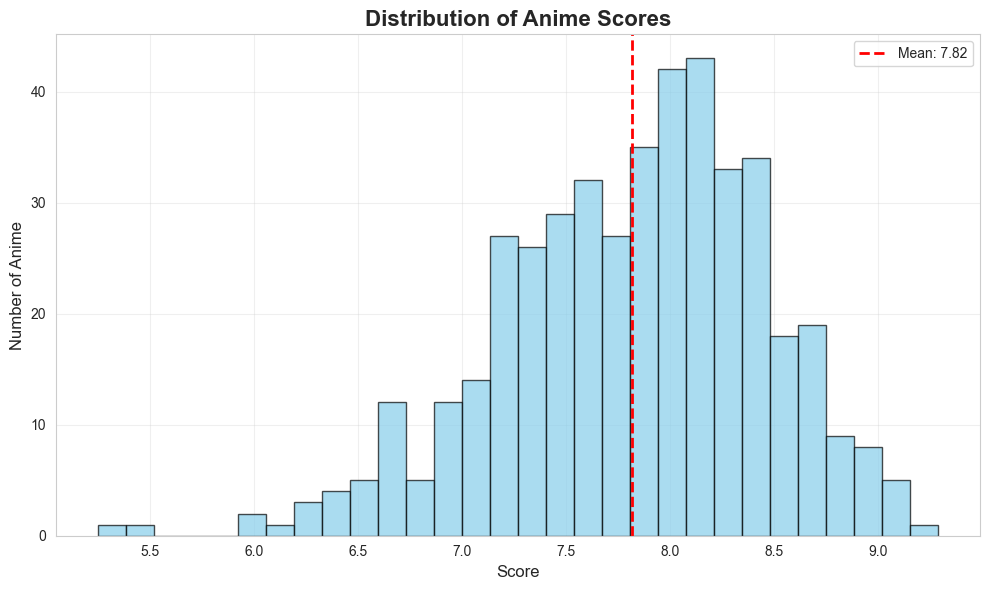

Chart saved to ../data/visualizations/score_distribution.png


In [17]:
plt.figure(figsize=(10, 6))
plt.hist(df['score'], bins=30, edgecolor='black', color='skyblue', alpha=0.7)
mean_score = df['score'].mean()
plt.axvline(mean_score, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_score:.2f}')

plt.title('Distribution of Anime Scores', fontsize=16, fontweight='bold')
plt.xlabel('Score', fontsize=12)
plt.ylabel('Number of Anime', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/visualizations/score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart saved to ../data/visualizations/score_distribution.png")

### Observations:
- Most anime scores are between 7.5 and 8.5
- Very few anime below 6.0

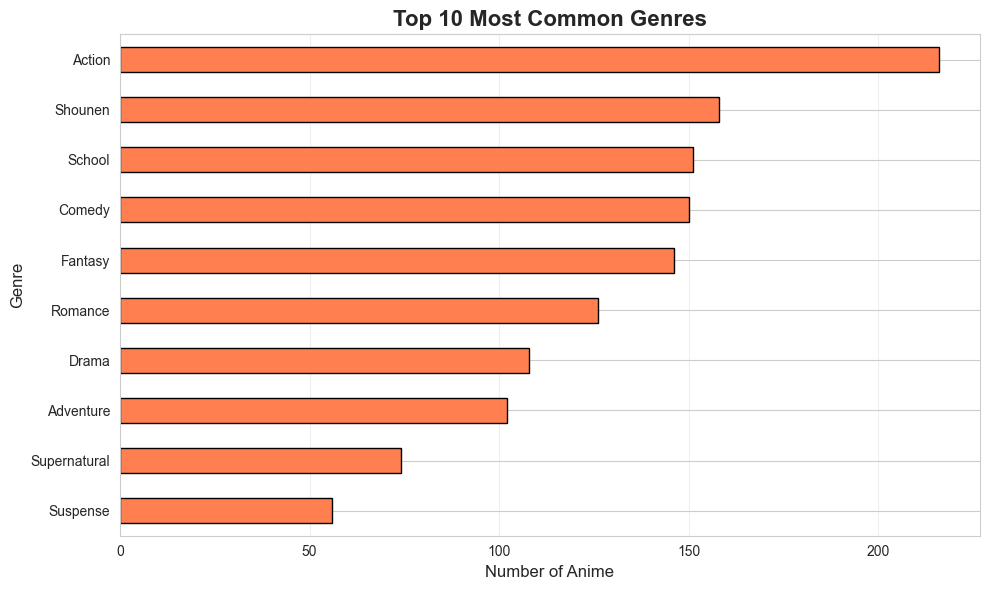

Found 73 unique genres
Chart saved!


In [7]:
df['genres'] = df['genres'].apply(ast.literal_eval)

all_genres = []
for genres_list in df['genres']:
    all_genres.extend(genres_list)

genre_counts = pd.Series(all_genres).value_counts().head(10)

plt.figure(figsize=(10,6))
genre_counts.plot(kind='barh', color='coral', edgecolor='black')
plt.title('Top 10 Most Common Genres', fontsize=16, fontweight='bold')
plt.xlabel('Number of Anime', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../data/visualizations/top_genres.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Found {len(set(all_genres))} unique genres")
print("Chart saved!")

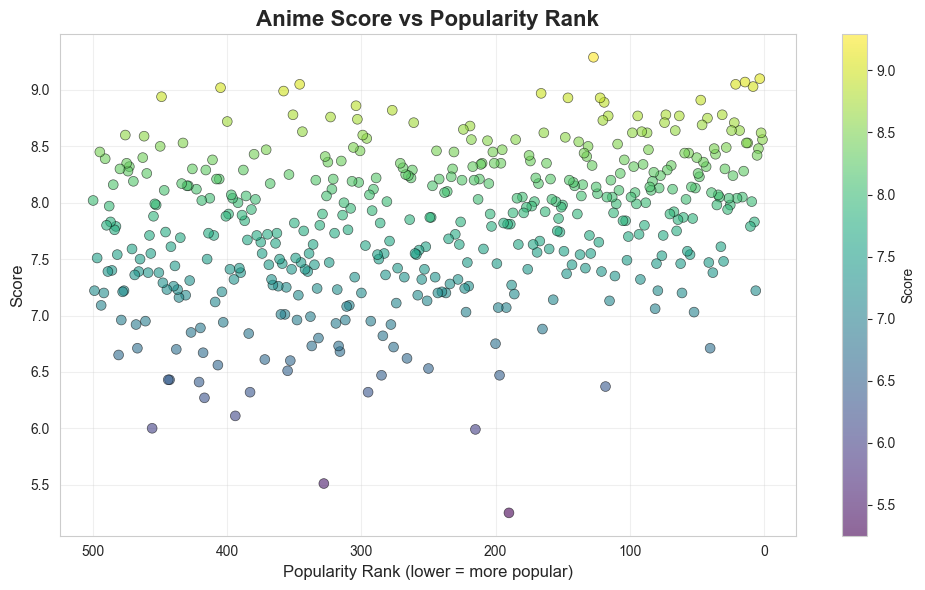

In [13]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(df['popularity'], df['score'],
                      c=df['score'], cmap='viridis',
                      alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

plt.colorbar(scatter, label="Score")

plt.title('Anime Score vs Popularity Rank', fontsize=16, fontweight='bold')
plt.xlabel('Popularity Rank (lower = more popular)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.gca().invert_xaxis()  # More popular on the right
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/visualizations/score_vs_popularity.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Summary

### Key Findings:
1. **Dataset Size:** Not all animes were scraped successfully. (448/500)
2. **Score Distribution:** Mean score of 7.82, most anime rated 7-9.
3. **Top Genres:** Action dominates, but Shounen, School, Comedy and Fantasy are also very popular.
4. **Quality vs Popularity:** Didn't spot a correlation between high scores and popularity, but animes with a score lower than 6.5 tend to be less popular.

In [14]:
df.to_csv('../data/processed/anime_clean.csv', index=False)
print("Cleaned data saved to ../data/processed/anime_clean.csv")

Cleaned data saved to ../data/processed/anime_clean.csv
